# Paralle Coordinates
Parallel coordinates are a common way to visualize high-dimensional data. In this representation, each attribute or dimension of the data is displayed as a vertical line, and individual observations are represented as polyline segments that connect these vertical lines at the corresponding values for each attribute. This allows you to see the relationships and patterns across multiple dimensions simultaneously. 

Characteristics
- introduced by Alfred Inselberg, IBM 1981
- most common technique today
- use one (parallel) axis for each variable/attribute
- all axes are (vertical) parallel
- each record (observation) is represented by a polygonal line, which connects the values of the attribute at each axis


### Paralle Coordinates with pandas

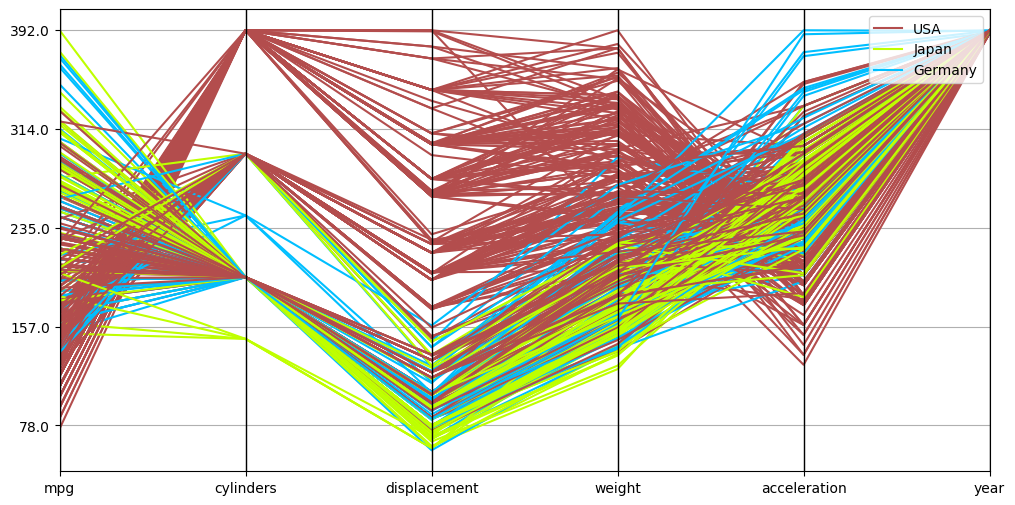

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Read the data from the CSV file
#cars = pd.read_csv('../data/Auto.csv')   
cars = pd.read_json('../../data/cars.json')
cars.head()
cars = cars[cars.horsepower != '?']
# Normalize data for better visualization
cols = ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'year']
# columne wise normalization
for col in cols:
    col_max = cars[col].max()
    cars[col] = cars[col] / col_max

# Change the origin code to country names
cars.apply({'origin': lambda x: x.replace(1,'USA',inplace=True)})
cars.apply({'origin': lambda x: x.replace(2,'Europe',inplace=True)})
cars.apply({'origin': lambda x: x.replace(3,'Japan',inplace=True)})
# Define the columns to use in the plot
cols = ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'year']
car_names = cars['name']
# Define the colors to use
colors = ['#b34d4d', '#bfff00', '#00bfff']
# Create a paralle coordinates plot
fig, ax = plt.subplots(figsize=(12, 6))
p = pd.plotting.parallel_coordinates(cars, 'origin', cols=cols, color=colors)
# Add ticks to y-axis
nr_rows = cars.shape[0]
ticks_loc = ax.get_yticks().tolist()
ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_loc))
yticks = []
for x in ticks_loc:
    yticks.append(str(round(x*nr_rows, 0)))
t = ax.set_yticklabels(yticks)
